In [ ]:
##### [실습 1] 모델 성능 최적화 : 과적합 모델 (Fashion-MNIST → 패션 관련 이미지) #####

In [1]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# 데이터 로더 함수
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

In [3]:
# 학습 함수
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

In [4]:
# 검증 함수
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred

In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [6]:
# 연습용 데이터 다운로드

from torchvision import datasets
from torchvision.transforms import ToTensor


train_dataset = datasets.FashionMNIST(root='data', train=True, download=True,
transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True,
transform=ToTensor())

100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



In [ ]:
# 답 확인 해보기

class_list = train_dataset.classes
class_list

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

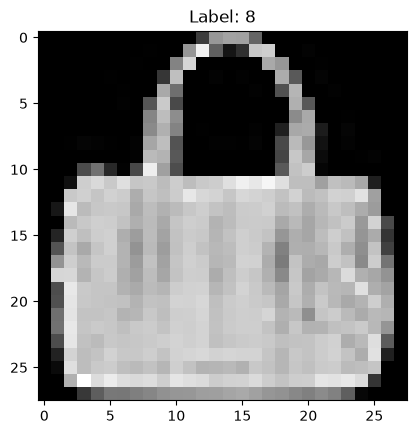

In [9]:
# 4000번째 이미지와 레이블의 답을 확인해 보기

n = 4000
image, label = train_dataset.data[n], train_dataset.targets[n]


# 이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [ ]:
# min max

x_train = train_dataset.data / 255
y_train = train_dataset.targets
x_test = test_dataset.data / 255
y_test = test_dataset.targets

In [ ]:
# 데이터 6만개에서 2만개로 줄임 (이건 저자가 학습 시간을 줄이기 위해서 임)

x_train = x_train[:20000]
y_train = y_train[:20000]
print(x_train.shape)    # ⭐차원 확인 (3차원 확인됨)

torch.Size([20000, 1, 28, 28])


In [12]:
# 학습용, 검증용 데이터 5천개씩 나누기

x_val, x_test = x_test[:5000], x_test[5000:]
y_val, y_test = y_test[:5000], y_test[5000:]
print(x_val.shape, x_test.shape)

torch.Size([5000, 28, 28]) torch.Size([5000, 28, 28])


In [ ]:
# ⭐차원 바꾸기 (3차원 -> 4차원)

x_train = x_train.view(20000, 1, 28, 28)    # 4차원으로 변경 (장수, 채널, 폭, 넓이), 채널 : 색
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)

In [15]:
# 텐서 데이터 셋으로 바꾸기

train_TensorDS = TensorDataset(x_train, y_train)
batch_size = 64
train_loader = DataLoader(train_TensorDS, batch_size=batch_size)

In [16]:
# 모델 만들기

n_feature = 28 * 28
n_class = 10
# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),
        nn.Linear(n_feature, 512), nn.ReLU(),
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 64), nn.ReLU(),
        nn.Linear(64, n_class)
        ).to(device)

In [ ]:
# 옵티마이저 적용

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [18]:
# summary 보기

from torchsummary import summary
summary(model, input_size = (n_feature,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 256]         131,328
              ReLU-5                  [-1, 256]               0
            Linear-6                  [-1, 256]          65,792
              ReLU-7                  [-1, 256]               0
            Linear-8                   [-1, 64]          16,448
              ReLU-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 616,138
Trainable params: 616,138
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.35
Estimated T

Epoch 1, train loss : 0.7336, val loss : 0.5783
Epoch 2, train loss : 0.4614, val loss : 0.4953
Epoch 3, train loss : 0.4088, val loss : 0.4429
Epoch 4, train loss : 0.3726, val loss : 0.4410
Epoch 5, train loss : 0.3471, val loss : 0.4418
Epoch 6, train loss : 0.3264, val loss : 0.4415
Epoch 7, train loss : 0.3075, val loss : 0.4434
Epoch 8, train loss : 0.2905, val loss : 0.4341
Epoch 9, train loss : 0.2717, val loss : 0.4580
Epoch 10, train loss : 0.2588, val loss : 0.4468
Epoch 11, train loss : 0.2478, val loss : 0.4612
Epoch 12, train loss : 0.2377, val loss : 0.4756
Epoch 13, train loss : 0.2269, val loss : 0.4688
Epoch 14, train loss : 0.2197, val loss : 0.4611
Epoch 15, train loss : 0.2089, val loss : 0.4962
Epoch 16, train loss : 0.2090, val loss : 0.4626
Epoch 17, train loss : 0.1988, val loss : 0.4754
Epoch 18, train loss : 0.2025, val loss : 0.4647
Epoch 19, train loss : 0.1945, val loss : 0.5011
Epoch 20, train loss : 0.1849, val loss : 0.5217
Epoch 21, train loss : 0.1804

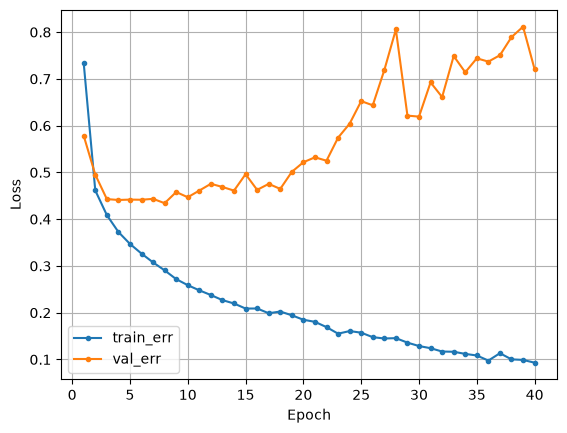

In [19]:
# 학습 시키기

epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)
    # 리스트에 추가
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)

In [ ]:
# 조기 종료

n_class = 10
model1= nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, n_class)
            ).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)


# 1. 조기 종료를 위한 변수 설정 ----------------
patience = 5    # 5번 동안 참겠다
best_loss = float('inf')
counter = 0
tr_loss_list, val_loss_list = [], []
for t in range(40):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


    # 2. 조기 종료 확인 -------------------
    if val_loss > best_loss:    # 오차가 줄지 않았다
        counter += 1
        print(f'--> status, best_loss : {best_loss:4f}, counter : {counter}')
    else:   # 개선 : 오차가 줄었다
        best_loss = val_loss
        counter = 0
    # 3. 조기 종료 조건 확인 --------------------
    if counter >= patience:
        print('Early Stopping!')
        break

Epoch 1, train loss : 0.7368, val loss : 0.5480
Epoch 2, train loss : 0.4691, val loss : 0.4787
Epoch 3, train loss : 0.4071, val loss : 0.4912
--> status, best_loss : 0.478744, counter : 1
Epoch 4, train loss : 0.3748, val loss : 0.4091
Epoch 5, train loss : 0.3444, val loss : 0.4205
--> status, best_loss : 0.409059, counter : 1
Epoch 6, train loss : 0.3223, val loss : 0.4062
Epoch 7, train loss : 0.2994, val loss : 0.4229
--> status, best_loss : 0.406234, counter : 1
Epoch 8, train loss : 0.2814, val loss : 0.4222
--> status, best_loss : 0.406234, counter : 2
Epoch 9, train loss : 0.2730, val loss : 0.4439
--> status, best_loss : 0.406234, counter : 3
Epoch 10, train loss : 0.2618, val loss : 0.4352
--> status, best_loss : 0.406234, counter : 4
Epoch 11, train loss : 0.2496, val loss : 0.4515
--> status, best_loss : 0.406234, counter : 5
Early Stopping!


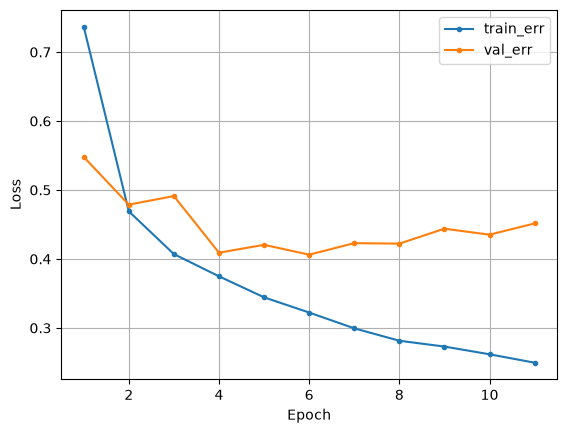

In [21]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [ ]:
# 드롭아웃

n_feature = 28 * 28
n_class = 10
dropout_rate = 0.4


model2 = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, n_class)
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

Epoch 1, train loss : 1.0329, val loss : 0.5987
Epoch 2, train loss : 0.6354, val loss : 0.5177
Epoch 3, train loss : 0.5614, val loss : 0.4977
Epoch 4, train loss : 0.5256, val loss : 0.4634
Epoch 5, train loss : 0.4912, val loss : 0.4478
Epoch 6, train loss : 0.4668, val loss : 0.4346
Epoch 7, train loss : 0.4500, val loss : 0.4185
Epoch 8, train loss : 0.4365, val loss : 0.4188
Epoch 9, train loss : 0.4224, val loss : 0.4161
Epoch 10, train loss : 0.4024, val loss : 0.4095
Epoch 11, train loss : 0.4037, val loss : 0.4064
Epoch 12, train loss : 0.3900, val loss : 0.4181
Epoch 13, train loss : 0.3943, val loss : 0.4154
Epoch 14, train loss : 0.3886, val loss : 0.4106
Epoch 15, train loss : 0.3719, val loss : 0.4255
Epoch 16, train loss : 0.3757, val loss : 0.4034
Epoch 17, train loss : 0.3632, val loss : 0.4131
Epoch 18, train loss : 0.3570, val loss : 0.4131
Epoch 19, train loss : 0.3527, val loss : 0.4172
Epoch 20, train loss : 0.3565, val loss : 0.4101
Epoch 21, train loss : 0.3495

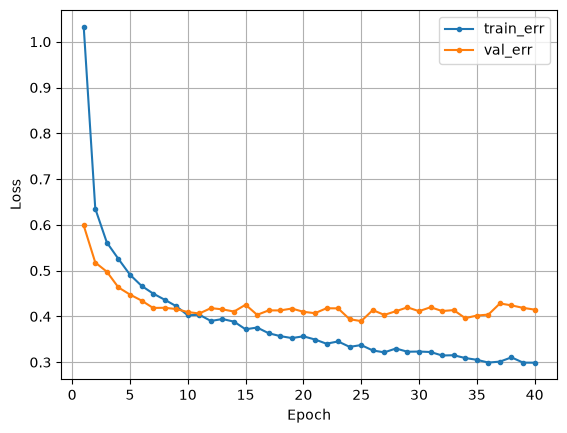

In [23]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)
    # 리스트에 추가
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


dl_learning_curve(tr_loss_list, val_loss_list)

In [24]:
# 가중치 규제

n_feature = 28 * 28
n_class = 10


model3 = nn.Sequential(nn.Flatten(),
            nn.Linear(n_feature, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, n_class)
            ).to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001, weight_decay = 0.001)

Epoch 1, train loss : 0.7771, val loss : 0.5961
Epoch 2, train loss : 0.5138, val loss : 0.5077
Epoch 3, train loss : 0.4572, val loss : 0.4751
Epoch 4, train loss : 0.4249, val loss : 0.4598
Epoch 5, train loss : 0.4056, val loss : 0.4502
Epoch 6, train loss : 0.3894, val loss : 0.4498
Epoch 7, train loss : 0.3687, val loss : 0.4645
Epoch 8, train loss : 0.3586, val loss : 0.4607
Epoch 9, train loss : 0.3407, val loss : 0.4615
Epoch 10, train loss : 0.3324, val loss : 0.4867
Epoch 11, train loss : 0.3205, val loss : 0.4643
Epoch 12, train loss : 0.3130, val loss : 0.4752
Epoch 13, train loss : 0.3013, val loss : 0.4679
Epoch 14, train loss : 0.2975, val loss : 0.4840
Epoch 15, train loss : 0.2919, val loss : 0.4440
Epoch 16, train loss : 0.2831, val loss : 0.4295
Epoch 17, train loss : 0.2811, val loss : 0.4309
Epoch 18, train loss : 0.2749, val loss : 0.4327
Epoch 19, train loss : 0.2637, val loss : 0.4390
Epoch 20, train loss : 0.2583, val loss : 0.4224
Epoch 21, train loss : 0.2606

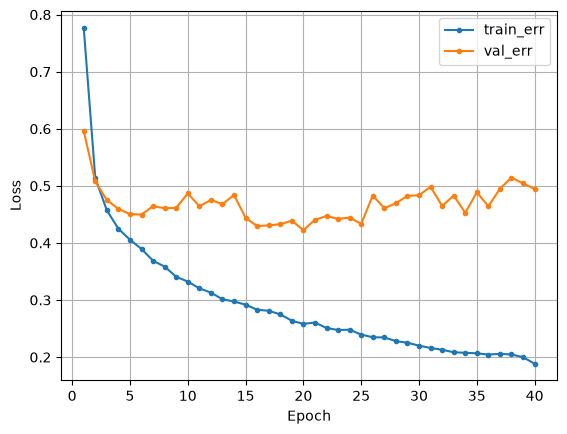

In [25]:
epochs = 40
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)
    tr_loss_list.append(tr_loss) # train - CrossEntropy
    val_loss_list.append(val_loss) # val - CrossEntropy
    print(f'Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}')


dl_learning_curve(tr_loss_list, val_loss_list)